# Multimodal Tweet Classification with Cross-Attention

This notebook implements a cross-attention based model for multimodal tweet classification, combining text and image features for better prediction accuracy.

In [11]:
cd ..

e:\notebooks


In [12]:
# Import required libraries
from exp.Required_Modules_And_Packages import *
from sample_data.Data_Reading_And_Preprocessing import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from torchvision.models import resnet50
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
import numpy as np
from tqdm import tqdm
import torch.multiprocessing as mp
import random
from sklearn.metrics import classification_report

# Set multiprocessing method
if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)

# Set device and random seeds for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
print(f"Using device: {device}")

Using device: cpu


## 1. Data Loading and Preprocessing

In [13]:
# Get tsv files for informative task
train_tsv, dev_tsv, test_tsv, info = get_tsv_data_files('Informativeness_task_tsv_files')

# Load and preprocess data
path = Path('E:/notebooks/MultimodalTweetsClassification')
data_info_text_image, test_data_info_text_image = get_dataframe(train_tsv, dev_tsv, test_tsv, info, path)

print(f"shape of data: {data_info_text_image.shape}\n")
print(f"train set: {data_info_text_image['is_valid'].value_counts()[0]}")
print(f"valid set: {data_info_text_image['is_valid'].value_counts()[1]}")      
print("="*50)
print(f"shape of test data: {test_data_info_text_image.shape}\n")

reading data and preprocessing it.....
done!!
shape of data: (914, 10)

train set: 804
valid set: 110
shape of test data: (107, 9)

done!!
shape of data: (914, 10)

train set: 804
valid set: 110
shape of test data: (107, 9)



## 2. Cross-Attention Model Architecture

We'll implement a cross-attention mechanism to fuse text and image features effectively.

In [ ]:
class CrossAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5

    def forward(self, x, context):
        q = self.query(x)
        k = self.key(context)
        v = self.value(context)

        attention = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attention = F.softmax(attention, dim=-1)
        out = torch.matmul(attention, v)
        return out


class MultimodalClassifier(nn.Module):
    def __init__(self, hidden_dim=512, num_classes=2, bert_model=None):
        super().__init__()

        # Image encoder (ResNet50)
        self.image_encoder = resnet50(pretrained=True)
        self.image_encoder.fc = nn.Identity()  # Remove final classification layer

        # Text encoder (BERT)
        self.text_encoder = bert_model if bert_model is not None else BertModel.from_pretrained(
            'bert-base-uncased')

        # Project both modalities to same dimension
        self.image_projection = nn.Linear(
            2048, hidden_dim)  # ResNet50 output dim is 2048
        self.text_projection = nn.Linear(
            768, hidden_dim)    # BERT output dim is 768

        # Cross attention layers
        self.img2text_attention = CrossAttention(hidden_dim)
        self.text2img_attention = CrossAttention(hidden_dim)

        # Final classification layers
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, images, input_ids, attention_mask):
        # Image features
        img_features = self.image_encoder(images)  # [batch_size, 2048]
        img_features = self.image_projection(
            img_features)  # [batch_size, hidden_dim]

        # Text features
        text_outputs = self.text_encoder(
            input_ids=input_ids, attention_mask=attention_mask)
        # Get the hidden states from the output tuple
        # First element contains hidden states
        last_hidden_state = text_outputs[0]
        text_features = last_hidden_state[:, 0, :]  # Use [CLS] token
        text_features = self.text_projection(
            text_features)  # [batch_size, hidden_dim]

        # Cross attention
        img_attended = self.text2img_attention(
            img_features.unsqueeze(1), text_features.unsqueeze(1))
        text_attended = self.img2text_attention(
            text_features.unsqueeze(1), img_features.unsqueeze(1))

        # Combine attended features
        fused_features = torch.cat(
            [img_attended.squeeze(1), text_attended.squeeze(1)], dim=-1)

        # Final classification
        output = self.fusion(fused_features)
        return output

In [15]:
# Get number of unique labels from the data
num_labels = len(data_info_text_image['label_text'].unique())
model_path = r"e:\notebooks\MultimodalTweetsClassification\bert_model"

print(f"Number of unique labels: {num_labels}")
print(f"Using BERT model from: {model_path}")

Number of unique labels: 2
Using BERT model from: e:\notebooks\MultimodalTweetsClassification\bert_model


## 3. Dataset and DataLoader

In [ ]:
class MultimodalDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, image_path, transform=None):
        self.df = df
        self.tokenizer = tokenizer
        self.image_path = image_path
        self.transform = transform
        # Create label mapping
        self.label_map = {'not_informative': 0, 'informative': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            # Process text
            text = str(row['tweet_text'])  # Ensure text is string
            # Don't use return_tensors='pt' here, we'll convert to tensor manually
            encoding = self.tokenizer.encode_plus(
                text,
                add_special_tokens=True,
                max_length=128,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors=None  # Return Python lists instead of tensors
            )

            # Process image
            image_path = self.image_path / row['image']
            image = Image.open(image_path).convert('RGB')
            if self.transform:
                image = self.transform(image)

            # Convert text label to numeric using label map
            label = torch.tensor(
                self.label_map[row['label_text']], dtype=torch.long)

            # Convert to tensors without batch dimension
            input_ids = torch.tensor(encoding['input_ids'], dtype=torch.long)
            attention_mask = torch.tensor(
                encoding['attention_mask'], dtype=torch.long)

        except Exception as e:
            print(f"Error processing item {idx}: {str(e)}")
            print(f"Text: {text}")
            print(f"Image path: {image_path}")
            raise

        # Ensure all tensors have the expected size
        if input_ids.dim() == 0:
            input_ids = input_ids.unsqueeze(0)
        if attention_mask.dim() == 0:
            attention_mask = attention_mask.unsqueeze(0)

        return {
            'image': image,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'label': label
        }


# Initialize tokenizer and transforms
print("Loading tokenizer...")
try:
    tokenizer = AutoTokenizer.from_pretrained(
        model_path)  # Use the same model path as BERT
    print("Tokenizer loaded successfully!")
except Exception as e:
    print(f"Error loading tokenizer: {str(e)}")
    print("Falling back to base BERT tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
    print("Base BERT tokenizer loaded successfully!")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_df = data_info_text_image[~data_info_text_image['is_valid']]
val_df = data_info_text_image[data_info_text_image['is_valid']]
test_df = test_data_info_text_image

print("Creating datasets...")
train_dataset = MultimodalDataset(
    train_df, tokenizer, path/'data/CrisisMMD_v2', transform)
val_dataset = MultimodalDataset(
    val_df, tokenizer, path/'data/CrisisMMD_v2', transform)
test_dataset = MultimodalDataset(
    test_df, tokenizer, path/'data/CrisisMMD_v2', transform)
print("Datasets created successfully!")

# Create custom collate function to handle batching


def custom_collate(batch):
    # Sort batch by sequence length (in descending order) to handle padding properly
    batch = sorted(batch, key=lambda x: len(x['input_ids']), reverse=True)

    # Get maximum sequence length in this batch
    max_len = len(batch[0]['input_ids'])

    # Initialize lists to store batch items
    images = []
    input_ids = []
    attention_masks = []
    labels = []

    for item in batch:
        # Handle images
        images.append(item['image'])

        # Pad input_ids and attention_mask if needed
        seq_len = len(item['input_ids'])
        if seq_len < max_len:
            # Padding token id is usually 0 for BERT
            padding = torch.zeros(max_len - seq_len, dtype=torch.long)
            item['input_ids'] = torch.cat([item['input_ids'], padding])
            item['attention_mask'] = torch.cat(
                [item['attention_mask'], padding])

        input_ids.append(item['input_ids'])
        attention_masks.append(item['attention_mask'])
        labels.append(item['label'])

    # Stack all tensors
    images = torch.stack(images)
    input_ids = torch.stack(input_ids)
    attention_masks = torch.stack(attention_masks)
    labels = torch.stack(labels)

    return {
        'image': images,
        'input_ids': input_ids,
        'attention_mask': attention_masks,
        'label': labels
    }

# Create data loaders with proper multiprocessing settings


def worker_init_fn(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


print("Creating data loaders...")
# Create data loaders with adjusted settings and custom collate function
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

print("Data loaders created successfully!")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Loading tokenizer...
Tokenizer loaded successfully!
Creating datasets...
Datasets created successfully!
Creating data loaders...
Data loaders created successfully!
Number of training samples: 804
Number of validation samples: 110
Number of test samples: 107
Data loaders created successfully!
Number of training samples: 804
Number of validation samples: 110
Number of test samples: 107


## 4. Training and Evaluation Functions

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # Using regular tqdm instead of notebook version
    for batch in tqdm(train_loader, desc='Training', leave=True):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar description
        if total % 100 == 0:
            print(
                f"\rLoss: {loss.item():.4f}, Acc: {100.*correct/total:.2f}%", end="")

    return total_loss / len(train_loader), 100.*correct/total


def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Evaluating', leave=True):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds))

    return total_loss / len(val_loader), 100.*correct/total

## 5. Model Training

In [ ]:
# Load local BERT model
print("Loading BERT model from local path...")
try:
    from transformers import AutoTokenizer, AutoModel
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    bert_model = AutoModel.from_pretrained(model_path)
    print("BERT model loaded successfully!")
except Exception as e:
    print(f"Error loading BERT model: {str(e)}")
    raise

# Initialize model with local BERT and correct number of classes
model = MultimodalClassifier(
    bert_model=bert_model, num_classes=num_labels).to(device)

# Ensure BERT is in training mode
model.text_encoder.train()

# Lists to store metrics for plotting
train_losses = []
train_accs = []
val_losses = []
val_accs = []

# Training parameters
num_epochs = 10
criterion = nn.CrossEntropyLoss()
# Lower learning rate for more stable training
optimizer = AdamW([
    {'params': model.image_encoder.parameters(), 'lr': 1e-5},
    {'params': model.text_encoder.parameters(), 'lr': 2e-6},  # Lower LR for BERT
    {'params': list(model.image_projection.parameters()) +
     list(model.text_projection.parameters()) +
     list(model.img2text_attention.parameters()) +
     list(model.text2img_attention.parameters()) +
     list(model.fusion.parameters()), 'lr': 2e-5}
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs)

# Training loop
best_val_acc = 0

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Store metrics for plotting
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f'\nTrain Loss: {train_loss:.4f} Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), path /
                   'models/best_multimodal_informative.pth')
        print(f'Saved new best model with validation accuracy: {val_acc:.2f}%')

Loading BERT model from local path...
BERT model loaded successfully!
BERT model loaded successfully!


Training:   0%|          | 0/51 [00:00<?, ?it/s]


Epoch 1/10
----------


Training:  49%|████▉     | 25/51 [03:34<03:30,  8.11s/it]

Loss: 0.4176, Acc: 82.50%

...

Loss: 0.0031, Acc: 99.75%

Training:  98%|█████████▊| 50/51 [07:55<00:09,  9.64s/it]

Loss: 0.0098, Acc: 99.88%

Evaluating: 100%|██████████| 7/7 [00:20<00:00,  2.97s/it]


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        67
           1       0.89      0.95      0.92        43

    accuracy                           0.94       110
   macro avg       0.93      0.94      0.93       110
weighted avg       0.94      0.94      0.94       110


Train Loss: 0.0081 Acc: 99.88%
Val Loss: 0.2268 Acc: 93.64%


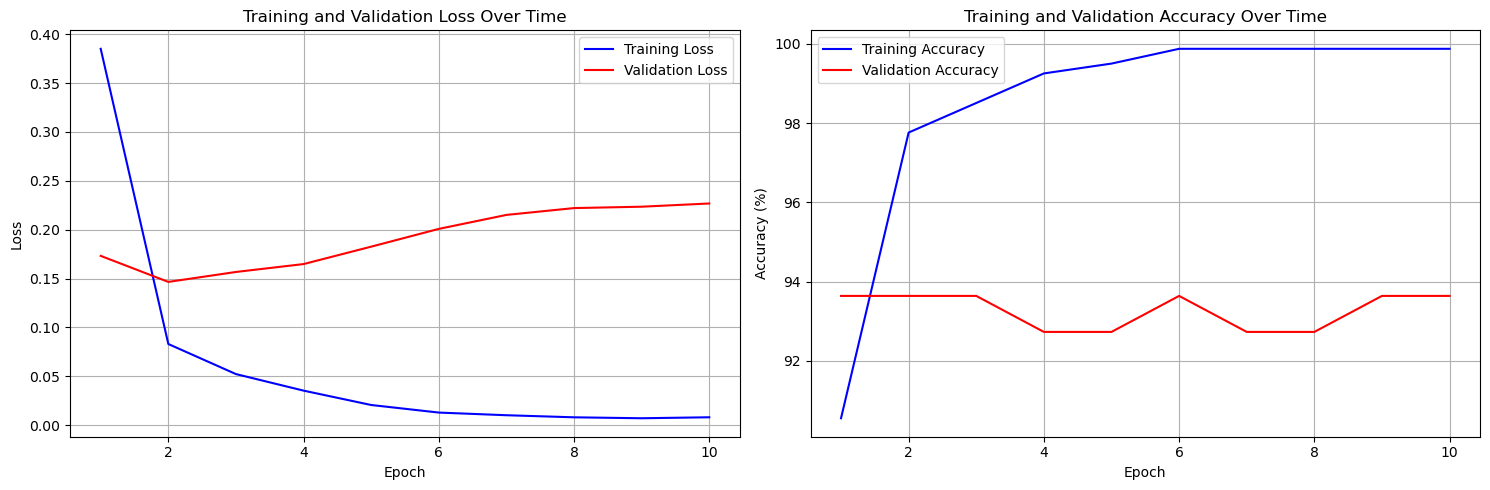


Final Results:
Best Validation Accuracy: 93.64%

Training History:
Epoch 1:
  Training   - Loss: 0.3850, Accuracy: 90.55%
  Validation - Loss: 0.1732, Accuracy: 93.64%
Epoch 2:
  Training   - Loss: 0.0830, Accuracy: 97.76%
  Validation - Loss: 0.1466, Accuracy: 93.64%
Epoch 3:
  Training   - Loss: 0.0522, Accuracy: 98.51%
  Validation - Loss: 0.1567, Accuracy: 93.64%
Epoch 4:
  Training   - Loss: 0.0353, Accuracy: 99.25%
  Validation - Loss: 0.1648, Accuracy: 92.73%
Epoch 5:
  Training   - Loss: 0.0206, Accuracy: 99.50%
  Validation - Loss: 0.1826, Accuracy: 92.73%
Epoch 6:
  Training   - Loss: 0.0129, Accuracy: 99.88%
  Validation - Loss: 0.2008, Accuracy: 93.64%
Epoch 7:
  Training   - Loss: 0.0101, Accuracy: 99.88%
  Validation - Loss: 0.2151, Accuracy: 92.73%
Epoch 8:
  Training   - Loss: 0.0080, Accuracy: 99.88%
  Validation - Loss: 0.2221, Accuracy: 92.73%
Epoch 9:
  Training   - Loss: 0.0071, Accuracy: 99.88%
  Validation - Loss: 0.2235, Accuracy: 93.64%
Epoch 10:
  Training   

In [ ]:
# Plotting training and validation metrics
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-', label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, 'b-', label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accs, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Results:")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print("\nTraining History:")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}:")
    print(
        f"  Training   - Loss: {train_losses[epoch]:.4f}, Accuracy: {train_accs[epoch]:.2f}%")
    print(
        f"  Validation - Loss: {val_losses[epoch]:.4f}, Accuracy: {val_accs[epoch]:.2f}%")

In [ ]:
# Load best model
model.load_state_dict(torch.load(
    path/'models/best_multimodal_informative.pth'))

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nTest Loss: {test_loss:.4f} Acc: {test_acc:.2f}%')

Evaluating: 100%|██████████| 7/7 [00:20<00:00,  2.88s/it]


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        74
           1       1.00      0.97      0.98        33

    accuracy                           0.99       107
   macro avg       0.99      0.98      0.99       107
weighted avg       0.99      0.99      0.99       107


Test Loss: 0.0961 Acc: 99.07%


In [ ]:
# Confusion Matrix and Detailed Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Function to get predictions for confusion matrix
def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Getting predictions'):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images, input_ids, attention_mask)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

# Get predictions for test set
print("Getting test set predictions...")
test_labels, test_preds = get_predictions(model, test_loader, device)

# Create label mapping for better visualization
label_map = {'not_informative': 0, 'informative': 1}
reverse_label_map = {v: k for k, v in label_map.items()}
class_names = [reverse_label_map[i] for i in range(len(label_map))]

# Create confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detailed classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Per-class accuracy analysis
print("\n" + "="*80)
print("PER-CLASS ACCURACY ANALYSIS")
print("="*80)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
for i, (class_name, accuracy) in enumerate(zip(class_names, class_accuracies)):
    total_samples = cm.sum(axis=1)[i]
    correct_samples = cm.diagonal()[i]
    print(f"{class_name:25}: {accuracy:.4f} ({correct_samples}/{total_samples} samples)")

# Plot per-class accuracy
plt.figure(figsize=(10, 6))
plt.bar(range(len(class_names)), class_accuracies, color='skyblue', alpha=0.8)
plt.xlabel('Class Labels', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy - Informative Classification', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on top of bars
for i, accuracy in enumerate(class_accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
overall_accuracy = np.trace(cm) / np.sum(cm)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")
print(f"Best Performing Class: {class_names[np.argmax(class_accuracies)]} ({class_accuracies.max():.4f})")
print(f"Worst Performing Class: {class_names[np.argmin(class_accuracies)]} ({class_accuracies.min():.4f})")
print(f"Average Per-Class Accuracy: {class_accuracies.mean():.4f}")
print(f"Standard Deviation: {class_accuracies.std():.4f}")

# Class distribution analysis
print("\n" + "="*80)
print("CLASS DISTRIBUTION IN TEST SET")
print("="*80)
unique_test, counts_test = np.unique(test_labels, return_counts=True)
for label_idx, count in zip(unique_test, counts_test):
    class_name = reverse_label_map[label_idx]
    percentage = count / len(test_labels) * 100
    print(f"{class_name:25}: {count:4d} samples ({percentage:.1f}%)")

# Additional metrics for binary classification
print("\n" + "="*80)
print("BINARY CLASSIFICATION METRICS")
print("="*80)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Precision (Informative): {precision:.4f}")
print(f"Recall (Informative):    {recall:.4f}")
print(f"Specificity:             {specificity:.4f}")
print(f"F1-Score:                {f1_score:.4f}")